In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA  
from sklearn.cluster import KMeans, AgglomerativeClustering
from kneed import KneeLocator
import pickle
import os 
print("All libraries imported successfully!")


All libraries imported successfully!


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 4: CONFIG — central constants dictionary
#
# WHY a CONFIG dict instead of hardcoding values inline?
# If n_clusters=4 is written in 10 different cells and you want
# to try K=5, you have to hunt down all 10 occurrences and risk
# missing one. Change CONFIG["n_clusters"] once → updates everywhere.
# ─────────────────────────────────────────────────────────────────

CONFIG = {
    # ── File paths ─────────────────────────────────────────────
    # All paths are relative to the PROJECT ROOT (segwise/)
    # not relative to the notebooks/ folder where this file lives
    "data_path":   "./data/smartcart_customers.csv",
    #               ↑ "../" goes up one level from notebooks/ to segwise/
    "model_dir":   "./models/",
    "output_dir":  "./outputs/",

    # ── Reproducibility ────────────────────────────────────────
    # random_state=42 passed to KMeans, PCA, and train/test splits
    # Same seed → same centroid initialisation → same result every run
    "random_state": 42,

    # ── Model settings ─────────────────────────────────────────
    # n_clusters validated by elbow + silhouette analysis in Cell 13
    "n_clusters":     4,

    # pca_components=3: gives 3D visualisability + retains ~60-80% variance
    # 2 = too little structure, 5+ = loses visualisability, marginal gain
    "pca_components": 3,

    # ── Outlier thresholds ─────────────────────────────────────
    # Age > 90: Year_Birth < 1936 → almost certainly a data entry error
    # Income > 600000: extreme single outlier drags centroid away from
    #                  the real cluster of normal-income customers
    "outlier_age_limit":    90,
    "outlier_income_limit": 600_000,

    # ── K search range ──────────────────────────────────────────
    "k_range": range(1, 11),   # test K = 1, 2, 3, ... 10
}

# Create output directories before any cell tries to write into them
# os.makedirs with exist_ok=True: no error if folder already exists
os.makedirs(CONFIG["model_dir"],  exist_ok=True)
os.makedirs(CONFIG["output_dir"], exist_ok=True)

print("✅ CONFIG loaded")
print(f"   data_path   = {CONFIG['data_path']}")
print(f"   model_dir   = {CONFIG['model_dir']}")
print(f"   output_dir  = {CONFIG['output_dir']}")
print(f"   n_clusters  = {CONFIG['n_clusters']}")

✅ CONFIG loaded
   data_path   = ./data/smartcart_customers.csv
   model_dir   = ./models/
   output_dir  = ./outputs/
   n_clusters  = 4


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 6: LOAD DATA + STRUCTURED EDA
# ─────────────────────────────────────────────────────────────────

# pd.read_csv: reads the CSV file into a DataFrame
# rows = individual customers, columns = features/attributes
df = pd.read_csv(CONFIG["data_path"])

# ALWAYS save a raw backup immediately after loading
# df_raw is NEVER modified — it's the safety net
# If any transformation breaks downstream, df_raw lets us restart
df_raw = df.copy()

print("=" * 60)
print("  SEGWISE — DATA EXPLORATION REPORT")
print("=" * 60)

# .shape returns (n_rows, n_columns) tuple
print(f"\n📦 Shape: {df.shape[0]} customers × {df.shape[1]} features")

# .dtypes: data type of each column
# object = string/text, int64 = integer, float64 = decimal
print("\n📋 Column types:")
print(df.dtypes.to_string())

# .isnull().sum(): count NaN per column
# boolean filter keeps only columns that actually have nulls
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\n❓ Missing values:")
print(missing.to_string() if len(missing) > 0 else "   None")

# .describe(): count, mean, std, min, Q1, Q2, Q3, max for numeric columns
print("\n📈 Statistical summary:")
print(df.describe().round(2).to_string())

# .value_counts(): frequency of each unique value in a column
print("\n🎓 Education distribution:")
print(df["Education"].value_counts().to_string())

print("\n💍 Marital status distribution:")
print(df["Marital_Status"].value_counts().to_string())

print("\n✅ df_raw saved as untouched reference copy")

  SEGWISE — DATA EXPLORATION REPORT

📦 Shape: 2240 customers × 22 features

📋 Column types:
ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Complain                 int64
Response                 int64

❓ Missing values:
Income    24

📈 Statistical summary:
             ID  Year_Birth     Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchas

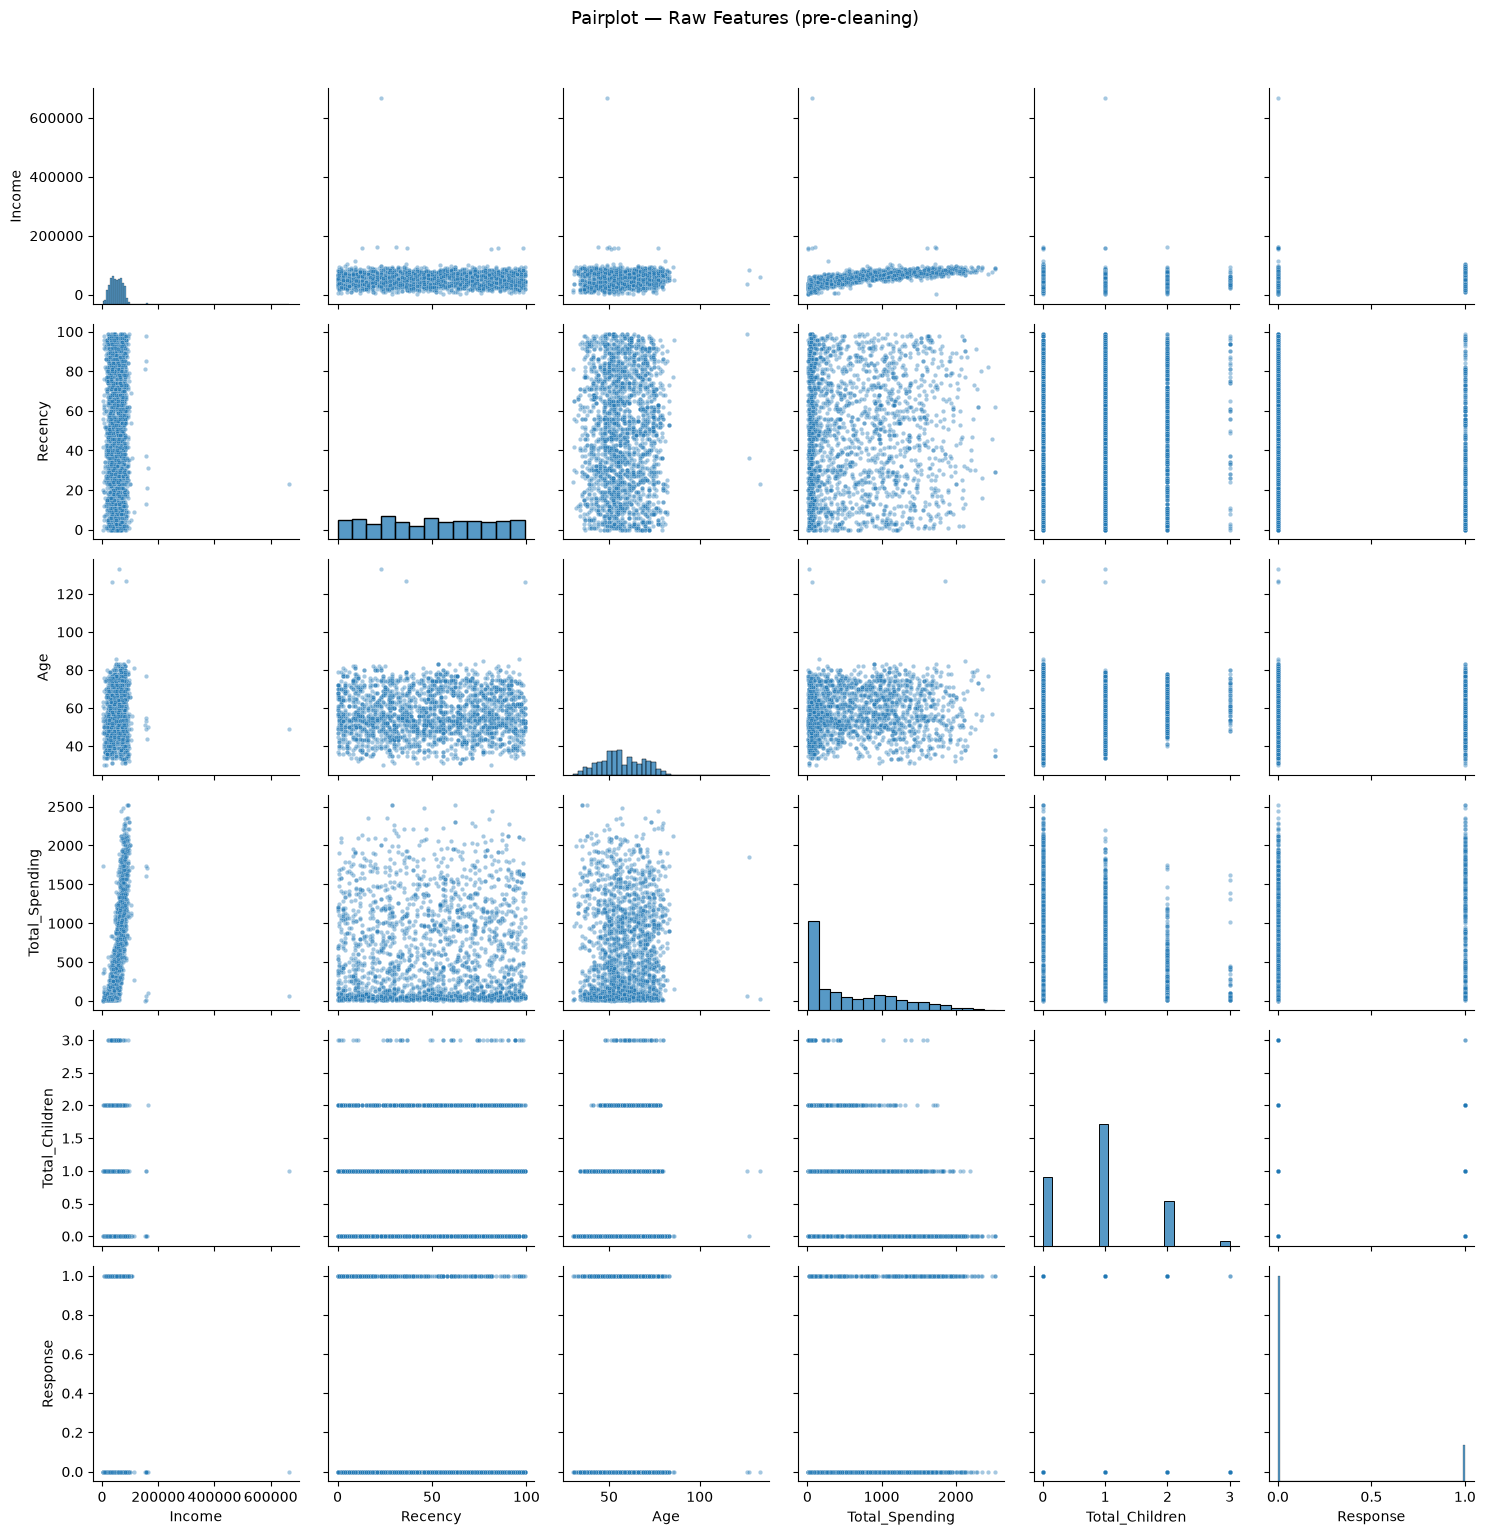

📸 Pairplot saved. Look for outlier points in Income and Age columns.


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 7: PAIRPLOT — visual outlier detection
#
# This is from your original solution.
# WHY pairplot BEFORE preprocessing?
# It visually reveals: outliers, skewed distributions, correlations.
# The extreme Age and Income points visible here are exactly what
# we filter out in Cell 11.
# ─────────────────────────────────────────────────────────────────

# Select a subset of columns — pairplot with all 22 is unreadable
cols_for_pairplot = ["Income", "Recency", "Age", "Total_Spending",
                     "Total_Children", "Response"]

# We need Age and Total_Spending computed first for the pairplot
# so we compute them temporarily here (without modifying df_raw)
df_temp = df_raw.copy()
df_temp["Age"] = 2026 - df_temp["Year_Birth"]
df_temp["Total_Spending"] = (
    df_temp["MntWines"] + df_temp["MntFruits"] + df_temp["MntMeatProducts"]
    + df_temp["MntFishProducts"] + df_temp["MntSweetProducts"] + df_temp["MntGoldProds"]
)
df_temp["Total_Children"] = df_temp["Kidhome"] + df_temp["Teenhome"]

# sns.pairplot: scatter matrix — every column vs every other column
# diag_kind="hist": show histogram on the diagonal (distribution of each feature)
# plot_kws={"alpha": 0.4}: semi-transparent points so overlap is visible
sns.pairplot(
    df_temp[cols_for_pairplot].dropna(),
    diag_kind="hist",
    plot_kws={"alpha": 0.4, "s": 10}
)
plt.suptitle("Pairplot — Raw Features (pre-cleaning)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] + "00_pairplot_raw.png", dpi=100, bbox_inches="tight")
plt.show()

# What to look for in this plot:
# Income column: one extreme point near 600,000 — visible outlier
# Age column: a few points above 90 — data entry errors
# Total_Spending vs Income: positive correlation — richer customers spend more
print("📸 Pairplot saved. Look for outlier points in Income and Age columns.")

del df_temp  # clean up temporary copy

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
df.shape

(2240, 22)

In [7]:
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing


### Handle Missing Values

In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 9: PREPROCESSING
# ─────────────────────────────────────────────────────────────────

# Always work on a copy — never mutate df_raw directly
df = df_raw.copy()

# ── Fix 1: Missing Income ──────────────────────────────────────
# 24 rows have NaN income (1.07% of data)
# WHY median not mean?
#   Income is RIGHT-SKEWED: a few millionaires pull the mean upward
#   mean   = easily distorted by one person earning 666,666
#   median = the literal middle value — not affected by extremes
#   Example: [20k, 30k, 40k, 50k, 900k] → mean=208k, median=40k
#   Median is the honest representative of "typical" income
df["Income"] = df["Income"].fillna(df["Income"].median())

# assert: crash IMMEDIATELY with a clear message if the fix failed
# Defensive programming: catch bugs at the source, not 10 cells later
assert df["Income"].isnull().sum() == 0, "Income still has NaN after fillna!"
print(f"✅ Income: {df_raw['Income'].isnull().sum()} nulls filled with median ({df['Income'].median():,.0f})")

# ── Fix 2: Parse Date Column ───────────────────────────────────
# Dt_Customer is stored as a STRING: "04-09-2012"
# We need a datetime object to compute how many days ago a customer joined
# dayfirst=True: format is DD-MM-YYYY not MM-DD-YYYY
#   Without dayfirst=True: "04-09-2012" → April 9 (wrong)
#   With    dayfirst=True: "04-09-2012" → September 4 (correct)
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

print(f"✅ Dt_Customer: string → datetime (dayfirst=True)")
print(f"   Sample: {df['Dt_Customer'].iloc[0]}  |  dtype: {df['Dt_Customer'].dtype}")
print(f"\n✅ Preprocessing done. Total nulls remaining: {df.isnull().sum().sum()}")

✅ Income: 24 nulls filled with median (51,382)
✅ Dt_Customer: string → datetime (dayfirst=True)
   Sample: 2012-09-04 00:00:00  |  dtype: datetime64[us]

✅ Preprocessing done. Total nulls remaining: 0


## Feature Engineering

In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 11: FEATURE ENGINEERING — 6 new features
# ─────────────────────────────────────────────────────────────────

# ── Feature 1: Age ─────────────────────────────────────────────
# Year_Birth=1972 → Age=54. Now |54 - 60| = 6 year gap makes sense.
# 2026 = the reference year of this analysis/deployment
from datetime import datetime

current_year = datetime.now().year
df["Age"] = current_year - df["Year_Birth"]
print(f"✅ Age — range: {df['Age'].min()} to {df['Age'].max()} years")

# ── Feature 2: Customer Tenure Days ───────────────────────────
# How long has this customer been with SmartCart?
# Long tenure → loyal veteran (needs retention strategy)
# Short tenure → new user (needs onboarding strategy)
#
# reference_date = most recent enrollment in the dataset = "today"
# (reference_date - join_date) → TimeDelta → .dt.days → integer
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days
print(f"✅ Customer_Tenure_Days — range: {df['Customer_Tenure_Days'].min()} to {df['Customer_Tenure_Days'].max()} days")

# ── Feature 3: Total Spending ──────────────────────────────────
# 6 category columns (Wines, Fruits, Meat, Fish, Sweet, Gold) all
# measure the same concept: "how much does this person spend?"
# Keeping all 6 gives spending 6× more weight than income or age
# in Euclidean distance. One aggregate column = fair representation.
df["Total_Spending"] = (
    df["MntWines"]           # wine products spend
    + df["MntFruits"]        # fruit products spend
    + df["MntMeatProducts"]  # meat products spend
    + df["MntFishProducts"]  # fish products spend
    + df["MntSweetProducts"] # sweet products spend
    + df["MntGoldProds"]     # luxury/gold products spend
)
print(f"✅ Total_Spending — range: {df['Total_Spending'].min()} to {df['Total_Spending'].max()}")

# ── Feature 4: Total Children ──────────────────────────────────
# Kidhome + Teenhome → single family burden signal
# Families with children spend differently: less luxury, more necessities
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
print(f"✅ Total_Children — range: {df['Total_Children'].min()} to {df['Total_Children'].max()}")

# ── Feature 5: Education (simplified) ─────────────────────────
# Original 5 values → 3 meaningful tiers
# Fewer categories = fewer OHE columns = less noise for clustering
education_map = {
    "Basic":      "Undergraduate",  # no university degree
    "2n Cycle":   "Undergraduate",  # high school / diploma level
    "Graduation": "Graduate",       # completed bachelor's degree
    "Master":     "Postgraduate",   # master's degree
    "PhD":        "Postgraduate",   # doctoral degree
}
df["Education"] = df["Education"].replace(education_map)
print(f"✅ Education simplified → {sorted(df['Education'].unique())}")

# ── Feature 6: Living Situation ────────────────────────────────
# Original 7 values including "Absurd" and "YOLO" (data errors)
# → simplified to Partner | Alone
# Households with a partner typically have different budgets/spending
living_map = {
    "Married":  "Partner",
    "Together": "Partner",
    "Single":   "Alone",
    "Divorced": "Alone",
    "Widow":    "Alone",
    "Absurd":   "Alone",  # invalid data → mapped safely
    "YOLO":     "Alone",  # invalid data → mapped safely
}
df["Living_With"] = df["Marital_Status"].replace(living_map)
print(f"✅ Living_With → {sorted(df['Living_With'].unique())}")

print(f"\n✅ Feature engineering done. Shape: {df.shape}")

✅ Age — range: 30 to 133 years
✅ Customer_Tenure_Days — range: 0 to 699 days
✅ Total_Spending — range: 5 to 2525
✅ Total_Children — range: 0 to 3
✅ Education simplified → ['Graduate', 'Postgraduate', 'Undergraduate']
✅ Living_With → ['Alone', 'Partner']

✅ Feature engineering done. Shape: (2240, 27)


In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [16]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [17]:
# Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [18]:
#Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [20]:
#Education
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [21]:
# Undergraduate, Graduate, Postgraduate

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", 
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [22]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [23]:
# Marital Status
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [24]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

In [25]:
# Marital Status
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [26]:
## Drop Columns
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [27]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [28]:
cols = ["ID", "Year_Birth", "Marital_Status", "Dt_Customer", "Kidhome", "Teenhome"]

spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [29]:
df_cleaned.shape

(2240, 15)

In [30]:
df.shape

(2240, 27)

In [31]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers


In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 12: DROP COLUMNS + REMOVE OUTLIERS
# ─────────────────────────────────────────────────────────────────

# ── Drop replaced/irrelevant columns ──────────────────────────
cols_to_drop = (
    ["ID"]                                   # unique per row → zero clustering signal
    + ["Year_Birth"]                         # replaced by Age
    + ["Marital_Status"]                     # replaced by Living_With
    + ["Kidhome", "Teenhome"]               # replaced by Total_Children
    + ["Dt_Customer"]                        # replaced by Customer_Tenure_Days
    + ["MntWines", "MntFruits",             # all 6 replaced by Total_Spending
       "MntMeatProducts", "MntFishProducts",
       "MntSweetProducts", "MntGoldProds"]
)

print(f"Before: {df.shape[1]} columns")
df = df.drop(columns=cols_to_drop)
print(f"After:  {df.shape[1]} columns")
print(f"Kept: {list(df.columns)}")

# ── Remove outliers (from pairplot analysis in Cell 7) ────────
# Boolean masking: df[condition] keeps rows where condition=True
# More readable and faster than row-by-row .drop()
n_before = len(df)

# Age > 90: Year_Birth < 1936 → almost certainly data entry error
df = df[df["Age"] < CONFIG["outlier_age_limit"]]

# Income > 600,000: single extreme point drags centroid far from
# the real cluster of normal-income customers
df = df[df["Income"] < CONFIG["outlier_income_limit"]]

n_after = len(df)
print(f"\n✅ Outliers removed: {n_before} → {n_after} rows ({n_before - n_after} removed)")

# Save a reference to the cleaned (but not yet encoded) dataframe
# We'll need this again after clustering to attach persona labels
df_cleaned = df.copy()

Before: 27 columns
After:  15 columns
Kept: ['Education', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending', 'Total_Children', 'Living_With']

✅ Outliers removed: 2240 → 2236 rows (4 removed)


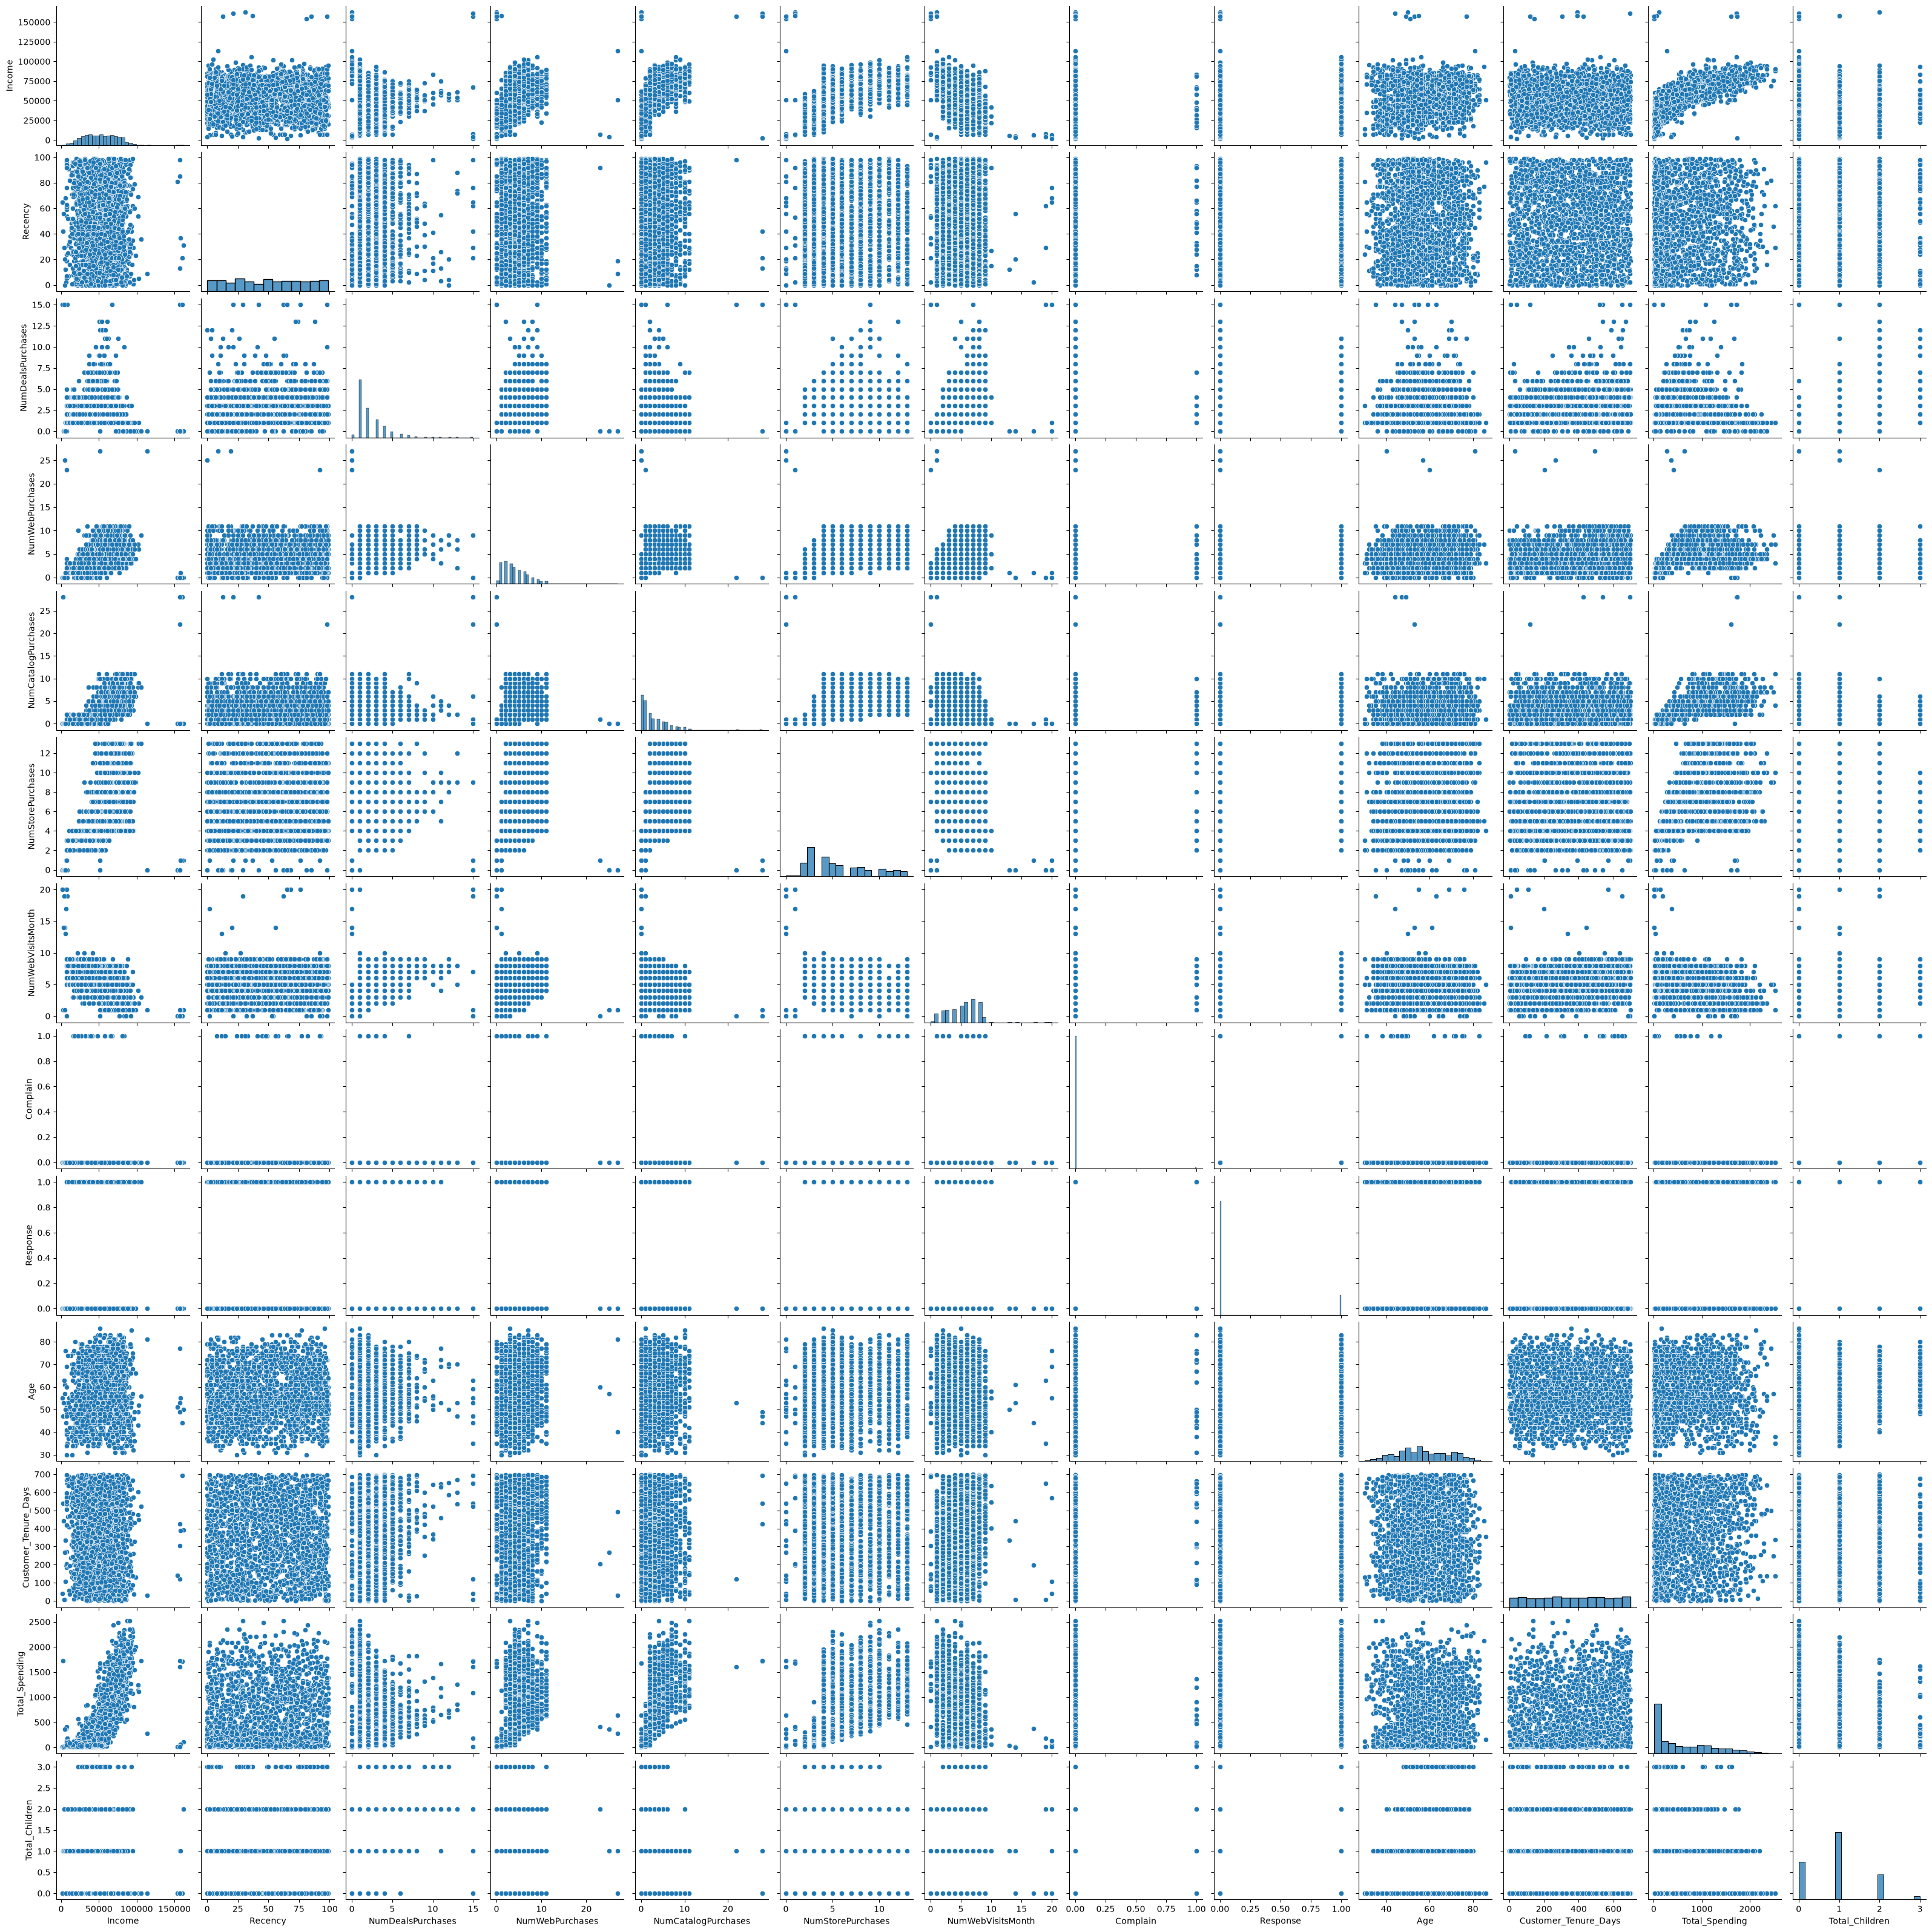

In [ ]:
cols =  ['Education', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending', 'Total_Children', 'Living_With']


#Relative Plots of Some Features - Pair Plots


sns.pairplot(df_cleaned[cols])

## Heatmap

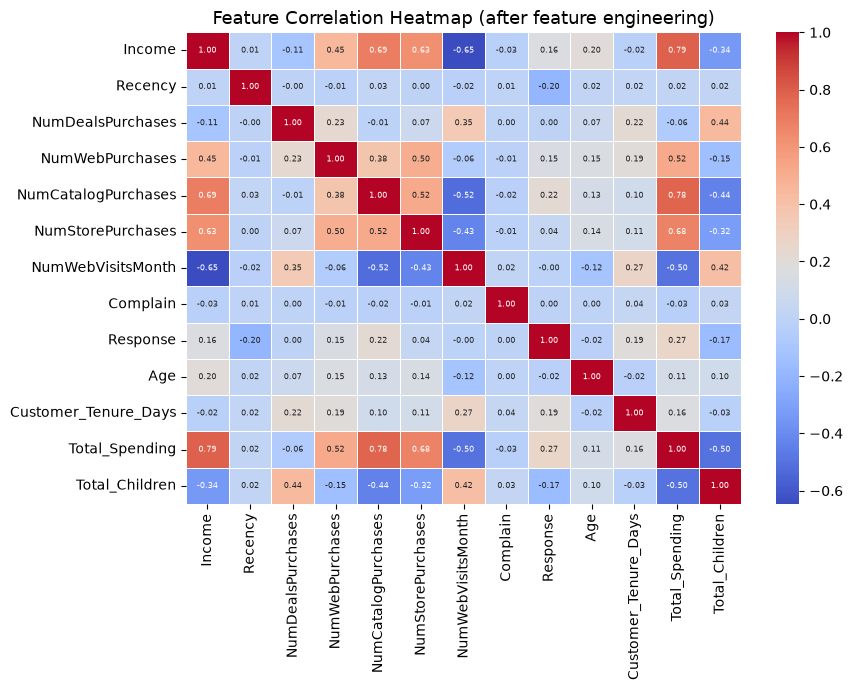

📸 Correlation heatmap saved.


In [13]:
# ─────────────────────────────────────────────────────────────────
# CELL 13: CORRELATION HEATMAP
#
# From your original solution — kept exactly here.
# WHY after feature engineering and cleaning?
# We want correlations on the FINAL feature set, not the raw columns.
# This confirms which features move together
# and validates our decision to aggregate spend columns.
# ─────────────────────────────────────────────────────────────────

# .corr(numeric_only=True): Pearson correlation between every pair
# of numeric columns. Range: -1 (perfect negative) to +1 (perfect positive)
corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,           # print the correlation value in each cell
    annot_kws={"size": 6},
    cmap="coolwarm",      # blue = negative, red = positive correlation
    fmt=".2f",            # 2 decimal places
    linewidths=0.5        # thin borders between cells
)
plt.title("Feature Correlation Heatmap (after feature engineering)", fontsize=13)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] + "00b_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# What to look for:
# Total_Spending should correlate positively with Income
# NumWebVisitsMonth might correlate negatively with spending (browsers not buyers)
# Highly correlated pairs confirm redundancy we've already handled
print("📸 Correlation heatmap saved.")

In [14]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

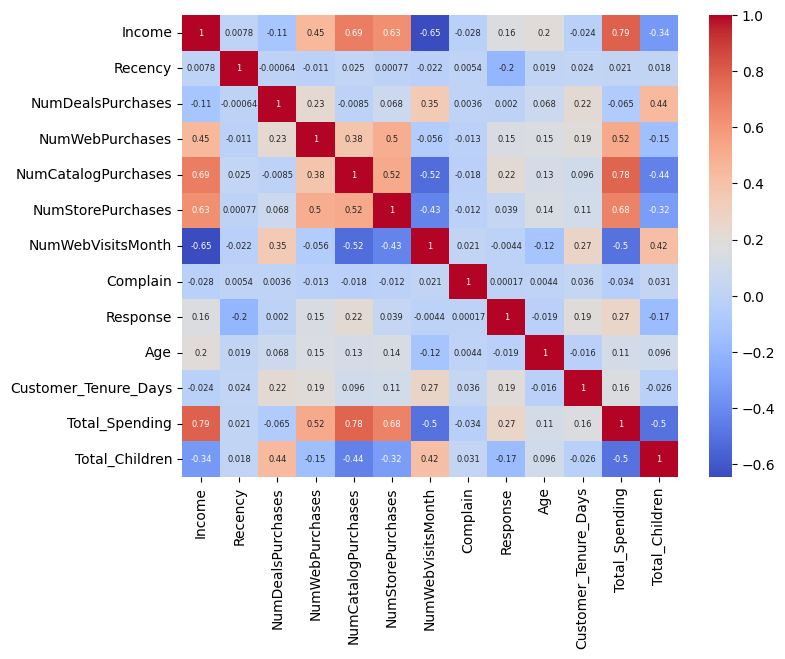

In [36]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm",

)

In [37]:
df_cleaned.shape

(2236, 15)

In [38]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Encoding


## 🔢 Step 4 — Encoding & Scaling
Convert text → numbers (OHE). Normalise all columns to same scale (StandardScaler).
Both are REQUIRED before any distance-based algorithm.
**Save both fitted objects — app.py reuses them for new customer predictions.**

In [15]:
# ─────────────────────────────────────────────────────────────────
# CELL 15: ONE-HOT ENCODING + STANDARD SCALING
# ─────────────────────────────────────────────────────────────────

cat_cols = ["Education", "Living_With"]

# ── One-Hot Encoding ───────────────────────────────────────────
# WHY OHE not LabelEncoder?
#   LabelEncoder: Graduate=0, Postgraduate=1, Undergraduate=2
#   → implies Postgraduate is "between" Graduate and Undergraduate
#   → that ordering is FALSE. OHE avoids it by creating separate columns.
#
# handle_unknown="ignore": if app.py sends a category never seen during
# training (e.g. "Diploma") → produce all zeros instead of crashing
# sparse_output=False: return a dense numpy array (no .toarray() call needed)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc_array = ohe.fit_transform(df[cat_cols])

# Build a proper DataFrame with column names from the encoder
enc_df = pd.DataFrame(
    enc_array,
    columns=ohe.get_feature_names_out(cat_cols),  # e.g. Education_Graduate
    index=df.index                                 # preserve original row indices
)

# pd.concat axis=1: horizontal join
# drop original text columns + append new binary columns
df_encoded = pd.concat(
    [df.drop(columns=cat_cols), enc_df],
    axis=1
)

print(f"✅ OneHotEncoding: {df.shape[1]} cols → {df_encoded.shape[1]} cols")
print(f"   New binary columns: {list(enc_df.columns)}")

# ── Standard Scaling ───────────────────────────────────────────
# Formula: z = (x - column_mean) / column_std
# Result: every column gets mean≈0 and std≈1
#
# WHY critical for KMeans / Agglomerative?
# Without scaling:
#   Income: 4,000 – 600,000  (range 596,000)
#   Complain: 0 or 1         (range 1)
# Income DOMINATES every distance. Complain is invisible to the model.
# After scaling: both have range ≈ [-2.5, +2.5] → equal contribution
#
# CRITICAL: we save the FITTED scaler object
# app.py must call scaler.transform() using the SAME mean + std
# computed here. A new scaler fitted on 1 row → wrong mean/std → wrong result
scaler = StandardScaler()

# fit_transform = compute mean + std from THIS data, then apply z-score
# Returns numpy array (not DataFrame) — sklearn always returns arrays
X_scaled = scaler.fit_transform(df_encoded)

# Verify: means ≈ 0, stds ≈ 1 (confirm scaling worked correctly)
print(f"\n✅ StandardScaler: shape {X_scaled.shape}")
print(f"   First 3 means (should be ≈ 0): {X_scaled.mean(axis=0)[:3].round(4)}")
print(f"   First 3 stds  (should be ≈ 1): {X_scaled.std(axis=0)[:3].round(4)}")

✅ OneHotEncoding: 15 cols → 18 cols
   New binary columns: ['Education_Graduate', 'Education_Postgraduate', 'Education_Undergraduate', 'Living_With_Alone', 'Living_With_Partner']

✅ StandardScaler: shape (2236, 18)
   First 3 means (should be ≈ 0): [-0. -0.  0.]
   First 3 stds  (should be ≈ 1): [1. 1. 1.]


In [42]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [44]:
df_encoded.shape

(2236, 18)

In [45]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


##  Scaling


In [47]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

In [48]:
X_scaled.shape

(2236, 18)

## 🔭 Step 5 — PCA: Dimensionality Reduction
22 features → 3 principal components.
PC1 = direction of maximum variance. PC2 = second most. PC3 = third most.
Result: 3D space we can visualise + faster, cleaner clustering.

✅ PCA: (2236, 18) → (2236, 3)
   PC1: 23.16%
   PC2: 11.39%
   PC3: 10.41%
   Total variance retained: 44.95%


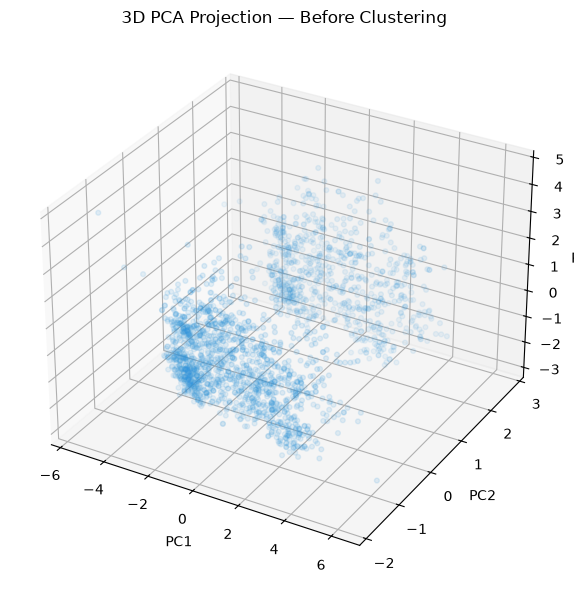

📸 Saved: 01_pca_raw.png


In [16]:
# ─────────────────────────────────────────────────────────────────
# CELL 17: PCA — Principal Component Analysis
# ─────────────────────────────────────────────────────────────────

# PCA intuition:
# Imagine 22 features as 22 axes in 22-dimensional space.
# Most axes are correlated (Income and Total_Spending move together).
# PCA finds 3 INDEPENDENT directions capturing the MOST spread.
# Like finding the 3 best "camera angles" to photograph 22D data.
#
# WHY 3 components?
# 1. 3D = visualisable as a scatter plot
# 2. Typically retains 60-80% of total variance
# 3. Dimensions 4+ mostly capture noise, not signal
#
# CRITICAL: save the fitted pca object
# app.py must call pca.transform() using the SAME eigenvectors
# computed here. A new PCA fitted elsewhere → different projection → wrong cluster
pca = PCA(n_components=CONFIG["pca_components"], random_state=CONFIG["random_state"])

# fit_transform: compute eigenvectors → project all customers onto top 3
# X_pca shape: (n_customers, 3) — three coordinates per customer
X_pca = pca.fit_transform(X_scaled)

# explained_variance_ratio_: fraction of total variance each PC captures
evr = pca.explained_variance_ratio_
print(f"✅ PCA: {X_scaled.shape} → {X_pca.shape}")
print(f"   PC1: {evr[0]*100:.2f}%")
print(f"   PC2: {evr[1]*100:.2f}%")
print(f"   PC3: {evr[2]*100:.2f}%")
print(f"   Total variance retained: {evr.sum()*100:.2f}%")

# ── 3D scatter BEFORE clustering ──────────────────────────────
# Shows the natural structure in data before any labels are applied
fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           alpha=0.4, s=12, c="#3498db")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection — Before Clustering", fontsize=12)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] + "01_pca_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Saved: 01_pca_raw.png")

In [51]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

# Analyse K Value
## 1. Elbow Method


## 🔢 Step 6 — Finding Optimal K
Two methods must agree before committing to a K value.
- **Elbow (WCSS):** where does the rate of improvement slow down?
- **Silhouette:** are the clusters actually well-separated?
- **KneeLocator:** removes human subjectivity from the elbow decision.

🔍 Testing K = 1 to 10...

  K= 1 | WCSS=      18,093 | Silhouette=N/A
  K= 2 | WCSS=      10,761 | Silhouette=0.3716
  K= 3 | WCSS=       8,210 | Silhouette=0.3676
  K= 4 | WCSS=       6,315 | Silhouette=0.3984
  K= 5 | WCSS=       5,004 | Silhouette=0.4004
  K= 6 | WCSS=       4,320 | Silhouette=0.4030
  K= 7 | WCSS=       3,666 | Silhouette=0.3984
  K= 8 | WCSS=       3,207 | Silhouette=0.4051
  K= 9 | WCSS=       2,824 | Silhouette=0.4085
  K=10 | WCSS=       2,486 | Silhouette=0.4073

📊 Elbow says:      K = 4
📊 Silhouette says: K = 9
📌 Using:           K = 4 (from CONFIG)


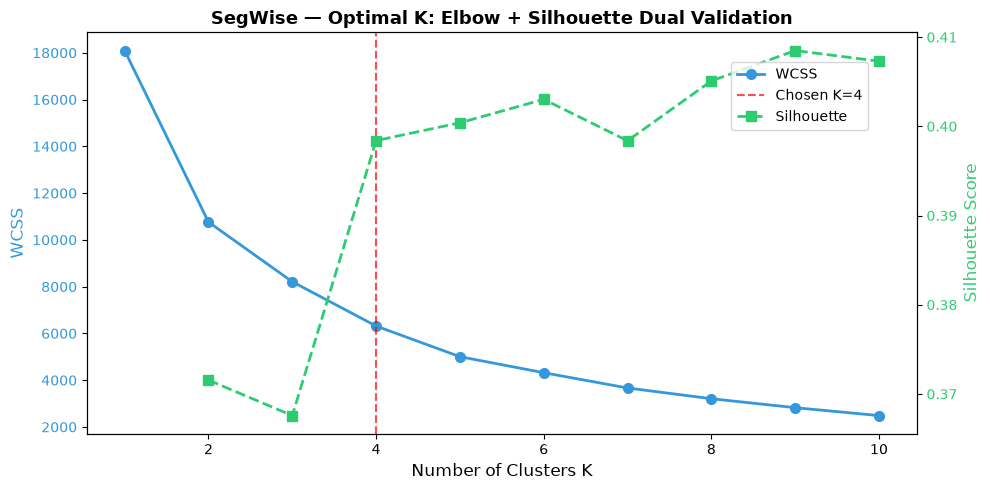

📸 Saved: 02_optimal_k.png


In [18]:
# ─────────────────────────────────────────────────────────────────
# CELL 19: OPTIMAL K — ELBOW + SILHOUETTE + KNEELOCATOR
# ─────────────────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score

wcss        = []  # Within-Cluster Sum of Squares per K
silhouettes = []  # Silhouette score per K (only for K≥2)

print("🔍 Testing K = 1 to 10...\n")

for k in CONFIG["k_range"]:

    # n_init=10: try 10 random starting positions, keep the best
    # prevents getting trapped in a bad local minimum
    km = KMeans(n_clusters=k, n_init=10, random_state=CONFIG["random_state"])
    labels_k = km.fit_predict(X_pca)

    # .inertia_ = WCSS value (always decreases as K increases)
    # We look for where the RATE of decrease drops sharply = the elbow
    wcss.append(km.inertia_)

    if k >= 2:
        # silhouette needs ≥2 clusters (can't compare "other cluster" at K=1)
        sil = silhouette_score(X_pca, labels_k)
        silhouettes.append(sil)
        print(f"  K={k:2d} | WCSS={km.inertia_:>12,.0f} | Silhouette={sil:.4f}")
    else:
        print(f"  K={k:2d} | WCSS={km.inertia_:>12,.0f} | Silhouette=N/A")

# KneeLocator: finds the mathematical elbow objectively
# curve="convex": WCSS curve bends like a convex bowl
# direction="decreasing": WCSS decreases as K increases
knee = KneeLocator(
    list(CONFIG["k_range"]), wcss,
    curve="convex", direction="decreasing"
)
optimal_k_elbow = knee.elbow

# Best silhouette K = index of max score + 2
# (silhouettes list starts at K=2, so index 0 = K=2)
optimal_k_sil = silhouettes.index(max(silhouettes)) + 2

print(f"\n📊 Elbow says:      K = {optimal_k_elbow}")
print(f"📊 Silhouette says: K = {optimal_k_sil}")
print(f"📌 Using:           K = {CONFIG['n_clusters']} (from CONFIG)")

# ── Combined dual-axis plot ────────────────────────────────────
# WCSS on left y-axis (blue), Silhouette on right y-axis (green)
# Both curves on same chart → easy to see where they agree
fig, ax1 = plt.subplots(figsize=(10, 5))
k_list = list(CONFIG["k_range"])
sil_ks = list(range(2, len(silhouettes) + 2))

# Left axis: WCSS
ax1.plot(k_list, wcss, "o-", color="#3498db", lw=2, ms=7, label="WCSS")
ax1.axvline(x=CONFIG["n_clusters"], color="red", ls="--", alpha=0.7,
            label=f"Chosen K={CONFIG['n_clusters']}")
ax1.set_xlabel("Number of Clusters K", fontsize=12)
ax1.set_ylabel("WCSS", fontsize=12, color="#3498db")
ax1.tick_params(axis="y", labelcolor="#3498db")

# Right axis: Silhouette (twinx = share x-axis, separate y-axis)
ax2 = ax1.twinx()
ax2.plot(sil_ks, silhouettes, "s--", color="#2ecc71", lw=2, ms=7, label="Silhouette")
ax2.set_ylabel("Silhouette Score", fontsize=12, color="#2ecc71")
ax2.tick_params(axis="y", labelcolor="#2ecc71")

plt.title("SegWise — Optimal K: Elbow + Silhouette Dual Validation", fontsize=13, fontweight="bold")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] + "02_optimal_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Saved: 02_optimal_k.png")

## 🤖 Step 7 — Fit Both Models, Auto-Select Winner
Train K-Means AND Agglomerative with K=4.
Compare silhouette scores. Higher score wins — data-driven, not hardcoded.

In [21]:
# ─────────────────────────────────────────────────────────────────
# CELL 21: FIT BOTH MODELS — AUTO-SELECT BY SILHOUETTE
# ─────────────────────────────────────────────────────────────────
import numpy as np

K = CONFIG["n_clusters"]

# ── K-Means ───────────────────────────────────────────────────
# n_init=20: 20 random initialisations → keeps the globally best result
# max_iter=500: hard stop if convergence is slow
kmeans        = KMeans(n_clusters=K, n_init=20, max_iter=500,
                       random_state=CONFIG["random_state"])
labels_kmeans = kmeans.fit_predict(X_pca)
sil_kmeans    = silhouette_score(X_pca, labels_kmeans)
print(f"✅ K-Means       | Silhouette = {sil_kmeans:.4f} | WCSS = {kmeans.inertia_:,.0f}")

# ── Agglomerative ─────────────────────────────────────────────
# linkage="ward": merge pairs that cause smallest WCSS increase
# Fully deterministic — no random state needed
agg        = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_agg = agg.fit_predict(X_pca)
sil_agg    = silhouette_score(X_pca, labels_agg)
print(f"✅ Agglomerative | Silhouette = {sil_agg:.4f}")

# ── Auto-select winner ─────────────────────────────────────────
# Higher silhouette = better cluster separation = better model
# This is DATA-DRIVEN selection — no hardcoded preference
if sil_agg >= sil_kmeans:
    best_labels = labels_agg
    best_model  = agg
    best_name   = "Agglomerative"
    best_sil    = sil_agg
else:
    best_labels = labels_kmeans
    best_model  = kmeans
    best_name   = "K-Means"
    best_sil    = sil_kmeans

print(f"\n🏆 Winner: {best_name}  (Silhouette = {best_sil:.4f})")
ids, counts = np.unique(best_labels, return_counts=True)
print(f"   Cluster distribution: { {int(i): int(c) for i, c in zip(ids, counts)} }")

✅ K-Means       | Silhouette = 0.3984 | WCSS = 6,315
✅ Agglomerative | Silhouette = 0.3793

🏆 Winner: K-Means  (Silhouette = 0.3984)
   Cluster distribution: {0: 821, 1: 621, 2: 351, 3: 443}


# Characterisation Of Clusters

In [78]:

X["cluster"] = labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

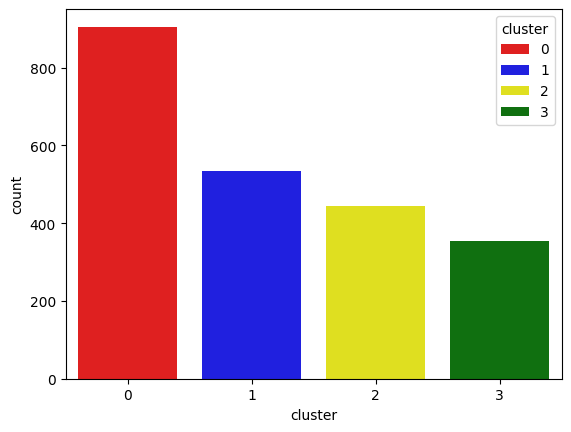

In [79]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

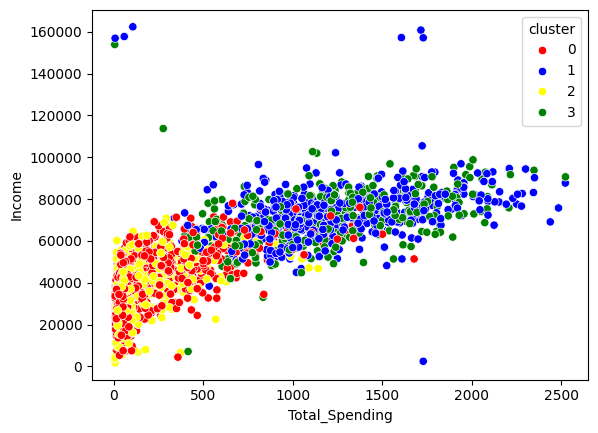

In [81]:
#Income And Spending Patterns
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [82]:
#Cluster Summary 
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         